In [1]:
!pip uninstall -y tensorflow
!pip install mediapipe==0.10.14 protobuf==4.25.9

In [2]:
import mediapipe as mp
print(mp.__version__)


0.10.14


In [3]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os
import copy
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Uzyskiwanie danych:

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data_dir = "/content/drive/MyDrive/1_DATASET_TENIS"
os.listdir(data_dir)


['waiting', 'backhand', 'forehand', 'serwis']

Inicjalizacja mediapipe

In [7]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [8]:
SELECT_LANDMARKS = [
    11, 12,  # barki
    13, 14,  # łokcie
    15, 16,  # nadgarstki
    23, 24,  # biodra
    25, 26,  # kolana
    27, 28   # kostki
]

funkcja ekstrakcji jedynie potrzebnych landmarków

In [9]:
def extract_simplified_landmarks(frame):
    """Zwraca wektor 48-elementowy: x,y,z,visibility dla wybranych punktów"""
    results = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    if not results.pose_landmarks:
        return None  # brak detekcji

    lm = []
    for idx in SELECT_LANDMARKS:
        p = results.pose_landmarks.landmark[idx]
        lm.extend([p.x, p.y, p.z, p.visibility])
    lm = np.array(lm).reshape(len(SELECT_LANDMARKS), 4)

    # centrowanie względem środka bioder - dziękitemu środek bioder staje się punktem (0, 0)
    hip_center = lm[6:8, :2].mean(axis=0)  # index 6 i 7 = lewe i prawe biodro
    lm[:, :2] -= hip_center

    # skalowanie względem szerokości barków - eliminacja odległości zawodnika od kamery
    # do usunięcia przy volejach
    shoulder_distance = np.linalg.norm(lm[0, :2] - lm[1, :2])  # barki
    lm[:, :2] /= shoulder_distance + 1e-6  # uniknięcie dzielenia przez 0

    return lm.flatten()  # finalnie shape = (48,)

In [10]:
def extract_all_landmarks_from_video(video_path):
    cap = cv2.VideoCapture(video_path) # odtwarzanie video klatka po klatce
    frames_landmarks = []
    last_valid = None

    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break

        landmarks = extract_simplified_landmarks(frame)

        if landmarks is not None:
            last_valid = landmarks
        else:
            if last_valid is not None:
                landmarks = last_valid
            else:
                continue

        frames_landmarks.append(landmarks)

    cap.release()

    return frames_landmarks

Dtataset dla Pytorcha

In [11]:
class PoseDataset(Dataset):
    def __init__(self, video_paths, labels, seq_len=20, stride=None):
        self.samples = []
        self.labels = []
        self.stride = stride if stride is not None else seq_len

        for i, video_path in enumerate(video_paths):
            label = labels[i]
            all_landmarks = extract_all_landmarks_from_video(video_path)

            if len(all_landmarks) < seq_len:
                continue

            for j in range(0, len(all_landmarks) - seq_len + 1, self.stride):
                sequence = all_landmarks[j:j+seq_len]
                self.samples.append(sequence)
                self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return (
            torch.tensor(np.array(self.samples[idx]), dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [12]:
# 1. Najpierw robimy listę wszystkich plików wideo na dysku
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
limit_per_class = 75

all_video_paths = []
all_video_labels = []

for cls in class_names:
    path = os.path.join(data_dir, cls)
    # Pobieramy ścieżki do filmów
    vids = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith('.mp4')]
    vids = vids[:limit_per_class]

    all_video_paths.extend(vids)
    all_video_labels.extend([class_to_idx[cls]] * len(vids))

# 2. KLUCZOWY MOMENT: Dzielimy listę ścieżek, a nie gotowe sekwencje!
# random_state=42 gwarantuje, że za każdym razem podział będzie taki sam
# Krok 1: Oddzielamy 70% na TRENING, a 30% zostawiamy na "resztę" (temp)
X_train_paths, X_temp_paths, y_train_labels, y_temp_labels = train_test_split(
    all_video_paths, all_video_labels, test_size=0.3, stratify=all_video_labels, random_state=42
)

# Krok 2: Dzielimy "resztę" na pół -> 15% WALIDACJA i 15% TEST
X_val_paths, X_test_paths, y_val_labels, y_test_labels = train_test_split(
    X_temp_paths, y_temp_labels, test_size=0.5, stratify=y_temp_labels, random_state=42
)

# 3. Teraz tworzymy trzy osobne datasety z tych list
print("Przygotowuję dane TRENINGOWE...")
train_dataset = PoseDataset(X_train_paths, y_train_labels, seq_len=20)

print("Przygotowuję dane WALIDACYJNE...")
val_dataset = PoseDataset(X_val_paths, y_val_labels, seq_len=20)

print("Przygotowuję dane TESTOWE...")
test_dataset = PoseDataset(X_test_paths, y_test_labels, seq_len=20)

# 4. Tworzymy Loadery
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"\nPodział zakończony sukcesem!")
print(f"Liczba sekwencji do nauki (Train): {len(train_dataset)}")
print(f"Liczba sekwencji do walidacji (Val): {len(val_dataset)}")
print(f"Liczba sekwencji do testu (Test): {len(test_dataset)}")

Przygotowuję dane TRENINGOWE (to potrwa)...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Przygotowuję dane TESTOWE (to potrwa)...

Podział zakończony sukcesem!
Liczba sekwencji do nauki: 1566
Liczba sekwencji do testu: 329


Architektura CN1D

In [13]:
class PoseCNN1D(nn.Module):
    def __init__(self, input_size=48, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv1d(input_size, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

Trening

In [14]:
model = PoseCNN1D(input_size=48, num_classes=4).to(device)

In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [18]:
epochs = 30
patience = 5
best_val_loss = float('inf')
counter = 0
best_model_wts = copy.deepcopy(model.state_dict()) # Tu zapiszemy najlepsze wagi

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            val_loss += loss.item()

            # dokładność
            predicted = torch.argmax(y_pred, dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) # Zapisujemy najlepsze wagi
        counter = 0 # Resetujemy licznik, bo nastąpiła poprawa
        print("   ---> Znaleziono lepszy model, zapisuję...")
    else:
        counter += 1
        print(f"   ---> Brak poprawy (licznik: {counter}/{patience})")
        if counter >= patience:
            print(f"Early Stopping! Przerywam trening w epoce {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Załadowano najlepsze zapisane wagi modelu.")


Epoch 1/30
Train Loss: 0.6767, Val Loss: 0.5727, Val Acc: 0.8243
   ---> Znaleziono lepszy model, zapisuję...
Epoch 2/30
Train Loss: 0.5668, Val Loss: 0.6243, Val Acc: 0.8275
   ---> Brak poprawy (licznik: 1/5)
Epoch 3/30
Train Loss: 0.5044, Val Loss: 0.4860, Val Acc: 0.8371
   ---> Znaleziono lepszy model, zapisuję...
Epoch 4/30
Train Loss: 0.4550, Val Loss: 0.5386, Val Acc: 0.8211
   ---> Brak poprawy (licznik: 1/5)
Epoch 5/30
Train Loss: 0.4846, Val Loss: 0.3870, Val Acc: 0.8882
   ---> Znaleziono lepszy model, zapisuję...
Epoch 6/30
Train Loss: 0.3681, Val Loss: 0.4240, Val Acc: 0.8786
   ---> Brak poprawy (licznik: 1/5)
Epoch 7/30
Train Loss: 0.3088, Val Loss: 0.4095, Val Acc: 0.9042
   ---> Brak poprawy (licznik: 2/5)
Epoch 8/30
Train Loss: 0.2810, Val Loss: 0.4188, Val Acc: 0.8946
   ---> Brak poprawy (licznik: 3/5)
Epoch 9/30
Train Loss: 0.3316, Val Loss: 0.8848, Val Acc: 0.8243
   ---> Brak poprawy (licznik: 4/5)
Epoch 10/30
Train Loss: 0.3902, Val Loss: 0.4763, Val Acc: 0.888

Test

In [19]:
def evaluate_model(model, loader, device, class_names):
    """
    Funkcja do przeprowadzania testu końcowego i generowania metryk.
    Wyświetla raport oraz dwie macierze pomyłek jedna pod drugą.
    """
    model.eval()
    all_preds = []
    all_labels = []

    print("Rozpoczynam ewaluację na zbiorze testowym...")

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # 1. Raport tekstowy
    print("\n" + "="*30)
    print("   RAPORT KLASYFIKACJI")
    print("="*30)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Obliczanie macierzy
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

    # 2. Wizualizacja obu macierzy jedna pod drugą
    # Zmieniamy na 2 wiersze, 1 kolumnę. Zwiększamy wysokość (figsize=(10, 16))
    fig, ax = plt.subplots(2, 1, figsize=(10, 16))

    # Macierz ilościowa (Górna)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title('Macierz Pomyłek (Ilościowa)')
    ax[0].set_xlabel('Przewidziane')
    ax[0].set_ylabel('Rzeczywiste')

    # Macierz proporcji (Dolna)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=ax[1])
    ax[1].set_title('Macierz Pomyłek (Proporcje / Skuteczność %)')
    ax[1].set_xlabel('Przewidziane')
    ax[1].set_ylabel('Rzeczywiste')

    plt.tight_layout() # Zapobiega nakładaniu się napisów
    plt.show()

Rozpoczynam ewaluację na zbiorze testowym...

   RAPORT KLASYFIKACJI
              precision    recall  f1-score   support

    backhand       0.80      0.85      0.82        55
    forehand       0.74      0.76      0.75        83
      serwis       0.88      0.91      0.89       139
     waiting       0.80      0.62      0.70        52

    accuracy                           0.82       329
   macro avg       0.80      0.79      0.79       329
weighted avg       0.82      0.82      0.81       329



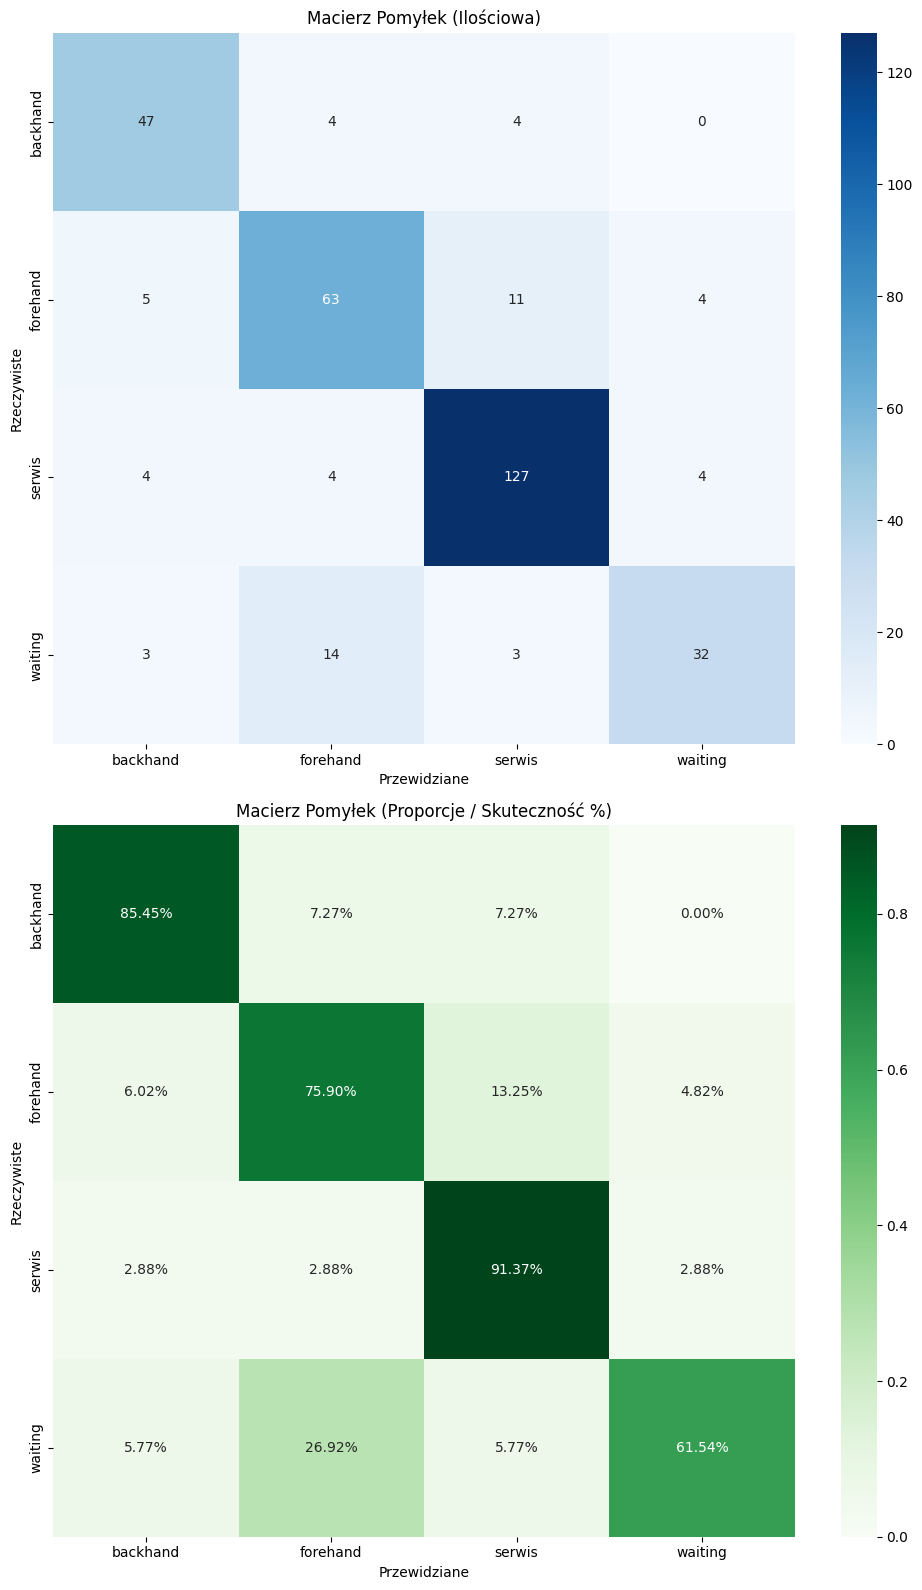

In [21]:
# Uruchom to po zakończeniu treningu
evaluate_model(
    model=model,
    loader=test_loader,
    device=device,
    class_names=class_names
)